In [1]:
%pip install graphviz

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 25.1.1
[notice] To update, run: python.exe -m pip install --upgrade pip


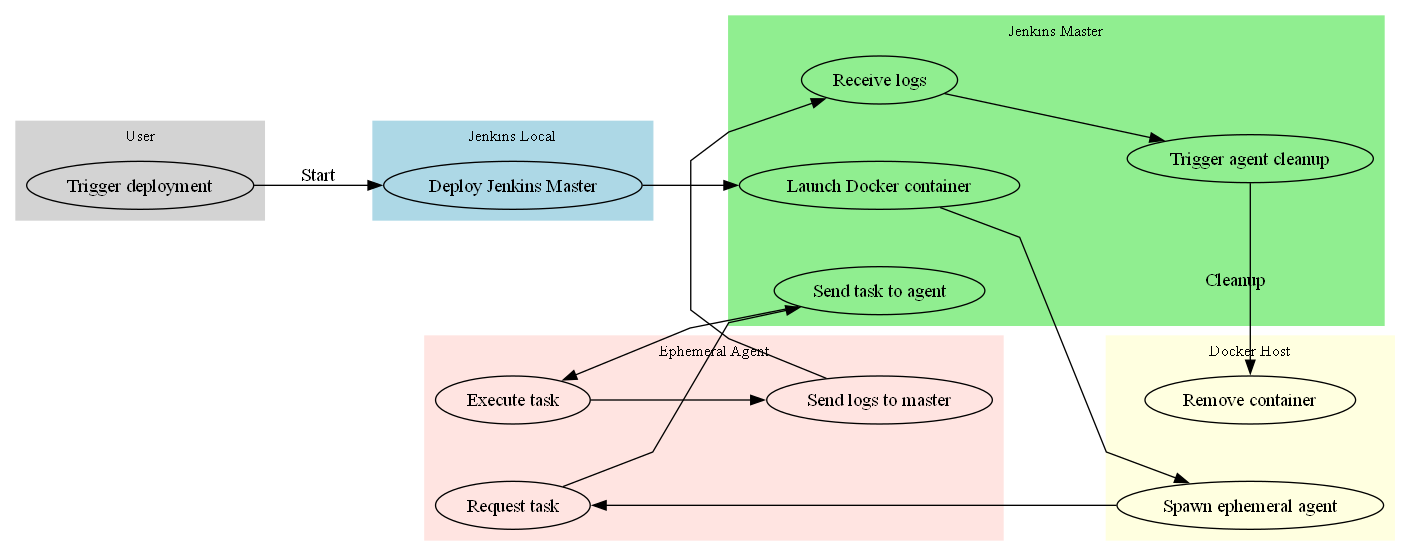

In [7]:
from graphviz import Digraph
from IPython.display import Image
import os

# Ensure Graphviz is in PATH
os.environ["PATH"] += os.pathsep + r"C:\Program Files (x86)\Graphviz\bin"

dot = Digraph('Jenkins_BPMN', format='png')
dot.attr(rankdir='LR', splines='polyline', nodesep='0.6', ranksep='1', fontsize='12')

# Swimlane clusters
with dot.subgraph(name='cluster_user') as user:
    user.attr(label='User', style='filled', color='lightgrey')
    user.node('trigger', 'Trigger deployment')

with dot.subgraph(name='cluster_local') as local:
    local.attr(label='Jenkins Local', style='filled', color='lightblue')
    local.node('deploy_master', 'Deploy Jenkins Master')

with dot.subgraph(name='cluster_master') as master:
    master.attr(label='Jenkins Master', style='filled', color='lightgreen')
    master.node('launch_docker', 'Launch Docker container')
    master.node('send_task', 'Send task to agent')
    master.node('collect_logs', 'Receive logs')
    master.node('cleanup_agent', 'Trigger agent cleanup')

with dot.subgraph(name='cluster_docker') as docker:
    docker.attr(label='Docker Host', style='filled', color='lightyellow')
    docker.node('spawn_agent', 'Spawn ephemeral agent')
    docker.node('remove_container', 'Remove container')

with dot.subgraph(name='cluster_agent') as agent:
    agent.attr(label='Ephemeral Agent', style='filled', color='mistyrose')
    agent.node('request_task', 'Request task')
    agent.node('execute_task', 'Execute task')
    agent.node('send_logs', 'Send logs to master')

# Process Flow
dot.edge('trigger', 'deploy_master', label='Start')
dot.edge('deploy_master', 'launch_docker')
dot.edge('launch_docker', 'spawn_agent')
dot.edge('spawn_agent', 'request_task')
dot.edge('request_task', 'send_task')
dot.edge('send_task', 'execute_task')
dot.edge('execute_task', 'send_logs')
dot.edge('send_logs', 'collect_logs')
dot.edge('collect_logs', 'cleanup_agent')
dot.edge('cleanup_agent', 'remove_container', label='Cleanup')

# Render and display
output_path = 'jenkins_bpmn_flow'
dot.render(output_path, cleanup=False)
Image(filename=output_path + ".png")
